# PANC Visual Demo

This notebook shows one didactic example on COCO with a query image that contains a person and a bicycle.

The flow is intentionally simple:
- download the query image and the two prior sets,
- show the masks overlaid on the images,
- extract DINOv3 patch features,
- segment the query with unsupervised NCut,
- segment the same query again with PANC using person priors and bicycle priors.

For the unsupervised baseline, NCut uses the mean Fiedler score as its threshold.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from pycocotools.coco import COCO

from panc import panc_segment
from utils.demo import (
    build_prior_bank,
    edge_aware_refine_mask,
    ensure_annotations_json,
    ensure_sample_asset,
    extract_patch_tokens,
    load_dinov3_backbone,
    overlay_mask,
    resize_image_and_mask,
)

PROJECT_ROOT = Path.cwd()
CACHE_DIR = PROJECT_ROOT / '.cache' / 'panc_demo'
IMAGES_DIR = CACHE_DIR / 'images'
MASKS_DIR = CACHE_DIR / 'masks'
ANNOTATIONS_DIR = CACHE_DIR / 'annotations'
DINO_REPO_DIR = CACHE_DIR / 'external' / 'dinov3'
WEIGHTS_PATH = PROJECT_ROOT / 'weights' / 'dinov3_vits16_pretrain_lvd1689m-08c60483.pth'
ANNOTATIONS_ZIP = CACHE_DIR / 'annotations_trainval2017.zip'
ANNOTATIONS_JSON = ANNOTATIONS_DIR / 'instances_val2017.json'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RESIZE_SIZE = 448
MAX_PATCHES_PER_CLASS_PER_IMAGE = 128

QUERY_SAMPLE = {
    'name': 'query_person_bicycle',
    'image_id': 343561,
    'file_name': '000000343561.jpg',
    'classes': ['person', 'bicycle'],
    'title': 'Query: person + bicycle',
}

PERSON_PRIORS = [
    {'name': 'prior_person_1', 'image_id': 441491, 'file_name': '000000441491.jpg', 'classes': ['person'], 'title': 'Person prior 1'},
    {'name': 'prior_person_2', 'image_id': 271997, 'file_name': '000000271997.jpg', 'classes': ['person'], 'title': 'Person prior 2'},
    {'name': 'prior_person_3', 'image_id': 445999, 'file_name': '000000445999.jpg', 'classes': ['person'], 'title': 'Person prior 3'},
]

BICYCLE_PRIORS = [
    {'name': 'prior_bicycle_1', 'image_id': 55022, 'file_name': '000000055022.jpg', 'classes': ['bicycle'], 'title': 'Bicycle prior 1'},
    {'name': 'prior_bicycle_2', 'image_id': 370208, 'file_name': '000000370208.jpg', 'classes': ['bicycle'], 'title': 'Bicycle prior 2'},
    {'name': 'prior_bicycle_3', 'image_id': 242287, 'file_name': '000000242287.jpg', 'classes': ['bicycle'], 'title': 'Bicycle prior 3'},
]

In [2]:
ANNOTATIONS_JSON.parent.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MASKS_DIR.mkdir(parents=True, exist_ok=True)

coco = COCO(str(ensure_annotations_json(CACHE_DIR, ANNOTATIONS_ZIP, ANNOTATIONS_JSON)))
query_sample = ensure_sample_asset(coco, QUERY_SAMPLE, IMAGES_DIR, MASKS_DIR)
person_prior_samples = [ensure_sample_asset(coco, sample, IMAGES_DIR, MASKS_DIR) for sample in PERSON_PRIORS]
bicycle_prior_samples = [ensure_sample_asset(coco, sample, IMAGES_DIR, MASKS_DIR) for sample in BICYCLE_PRIORS]

print(f'Device: {DEVICE}')
print(f'Query classes: {QUERY_SAMPLE["classes"]}')
print(f'Cache directory: {CACHE_DIR}')
print(f'Weights: {WEIGHTS_PATH.name}')

loading annotations into memory...
Done (t=0.32s)
creating index...
index created!
Device: cuda
Query classes: ['person', 'bicycle']
Cache directory: /home/jguti/Code/PANC/.cache/panc_demo
Weights: dinov3_vits16_pretrain_lvd1689m-08c60483.pth


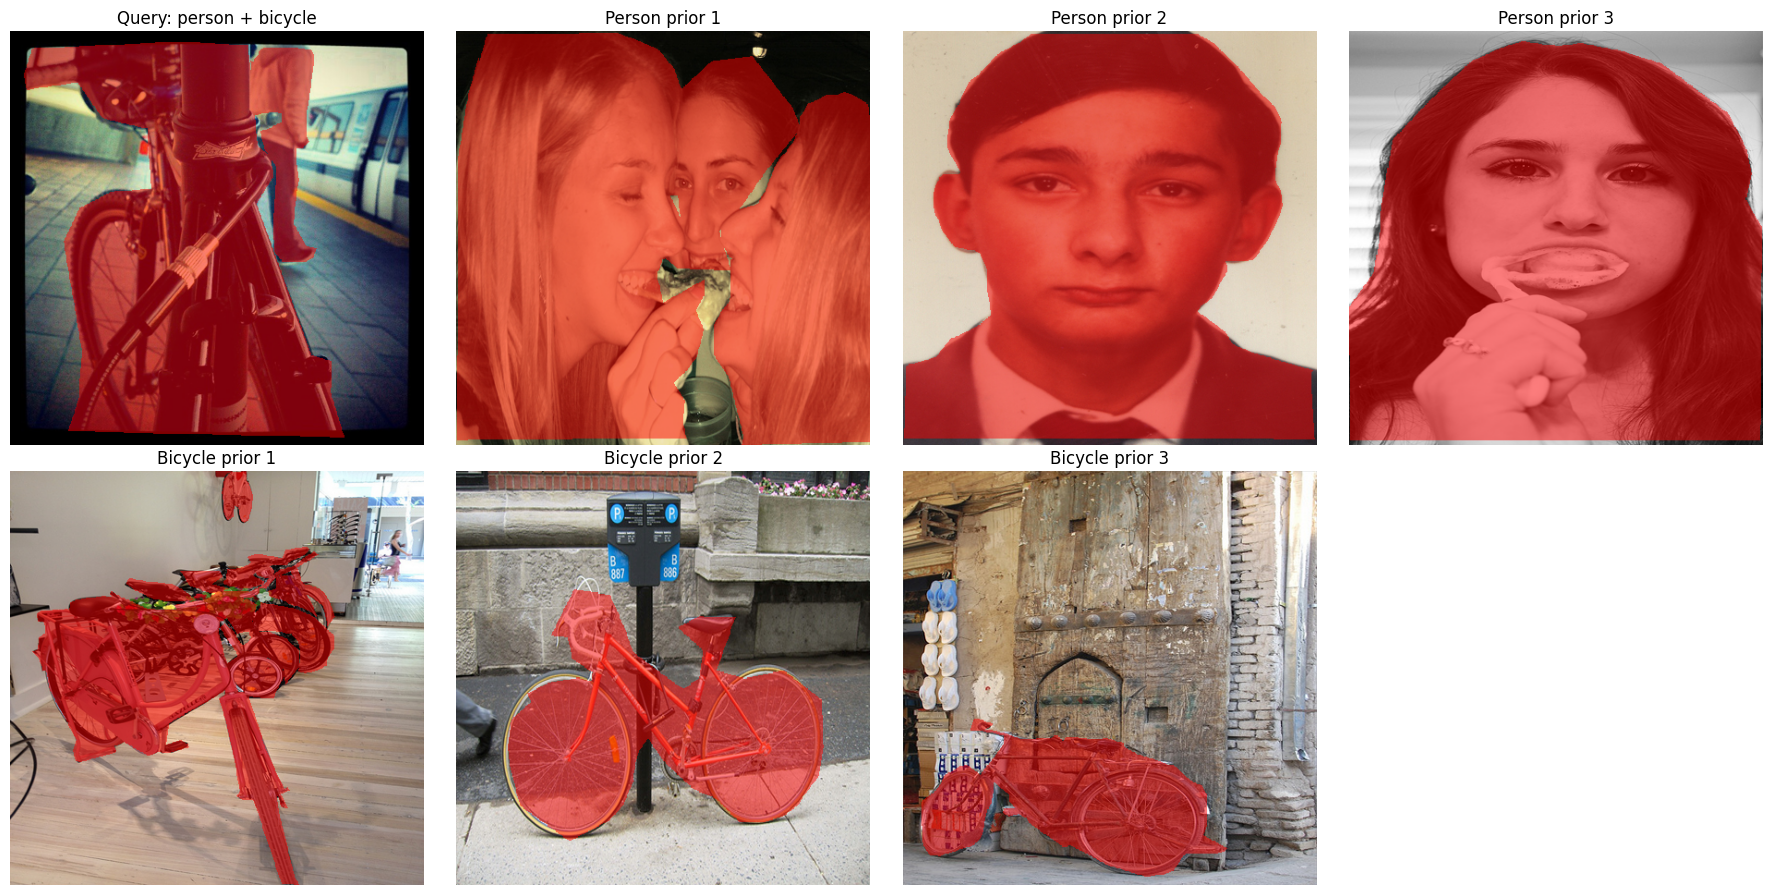

In [3]:
display_samples = [query_sample] + person_prior_samples + bicycle_prior_samples
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, sample in zip(axes.flat, display_samples):
    image, mask = resize_image_and_mask(sample['image_path'], sample['mask_path'], RESIZE_SIZE)
    ax.imshow(overlay_mask(image, mask))
    ax.set_title(sample['title'])
    ax.axis('off')

for ax in axes.flat[len(display_samples):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
model = load_dinov3_backbone(WEIGHTS_PATH, DINO_REPO_DIR, DEVICE)

query_image, query_union_mask = resize_image_and_mask(query_sample['image_path'], query_sample['mask_path'], RESIZE_SIZE)
query_features, grid_h, grid_w, query_image = extract_patch_tokens(model, query_image, RESIZE_SIZE, DEVICE)

person_prior_features, person_prior_labels = build_prior_bank(
    model,
    person_prior_samples,
    RESIZE_SIZE,
    DEVICE,
    max_patches_per_class_per_image=MAX_PATCHES_PER_CLASS_PER_IMAGE,
    seed=0,
)

bicycle_prior_features, bicycle_prior_labels = build_prior_bank(
    model,
    bicycle_prior_samples,
    RESIZE_SIZE,
    DEVICE,
    max_patches_per_class_per_image=MAX_PATCHES_PER_CLASS_PER_IMAGE,
    seed=1,
)

empty_prior_features = torch.empty((0, query_features.shape[1]), dtype=query_features.dtype)
empty_prior_labels = torch.empty((0,), dtype=torch.long)

print('Query features:', tuple(query_features.shape))
print('Person prior bank:', tuple(person_prior_features.shape))
print('Bicycle prior bank:', tuple(bicycle_prior_features.shape))

Query features: (784, 384)
Person prior bank: (702, 384)
Bicycle prior bank: (768, 384)


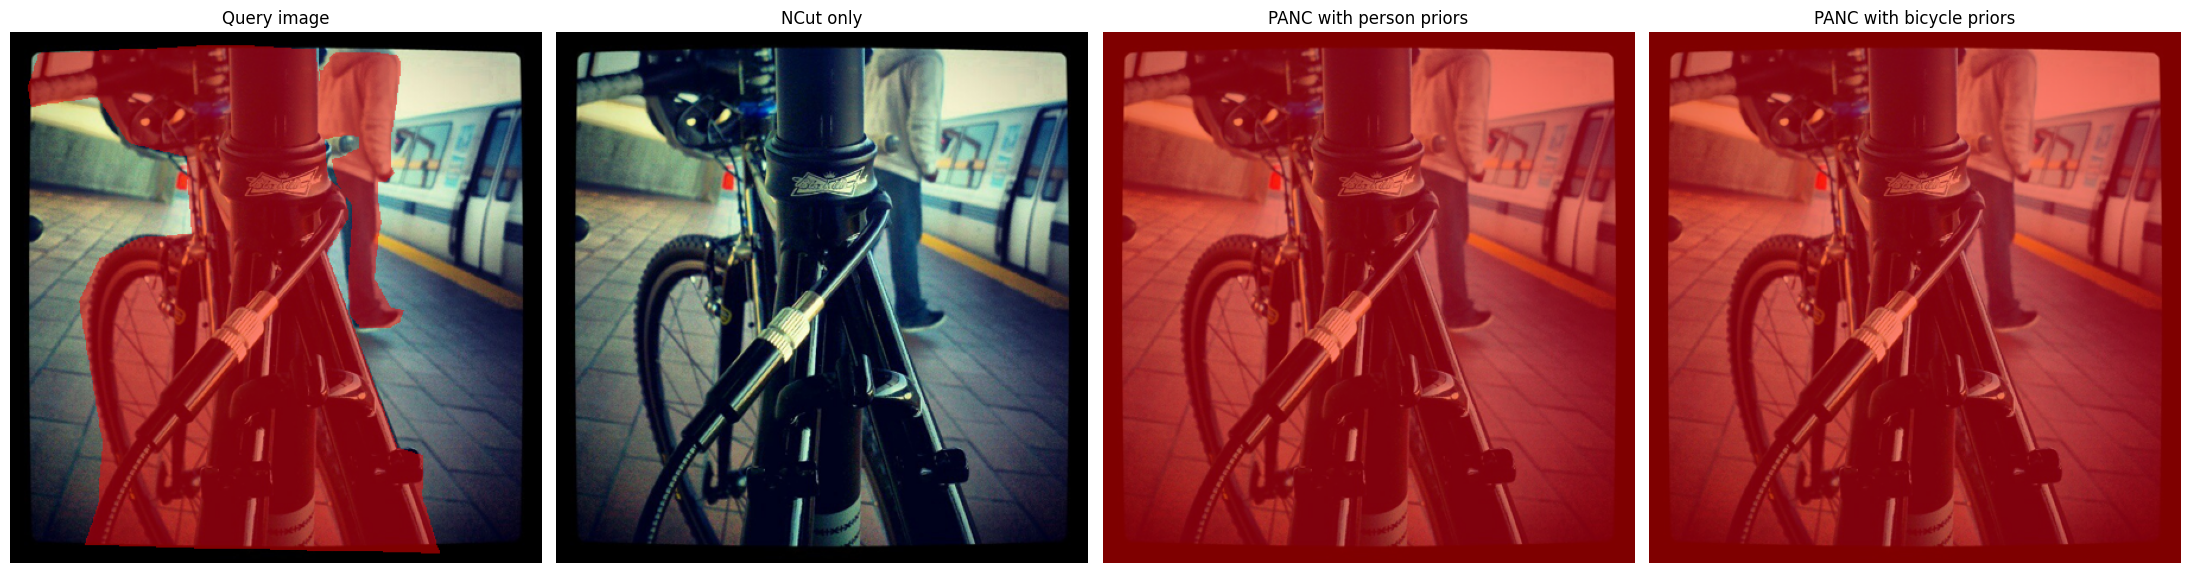

In [5]:
ncut_mask, ncut_scores, _, _, _, _ = panc_segment(
    query_features=query_features,
    prior_features=empty_prior_features,
    prior_labels=empty_prior_labels,
    tau=0.07,
    kappa=1.0,
)

person_mask, person_scores, _, _, _, _ = panc_segment(
    query_features=query_features,
    prior_features=person_prior_features,
    prior_labels=person_prior_labels,
    tau=0.07,
    kappa=1.0,
    threshold_strategy='roc',
)

bicycle_mask, bicycle_scores, _, _, _, _ = panc_segment(
    query_features=query_features,
    prior_features=bicycle_prior_features,
    prior_labels=bicycle_prior_labels,
    tau=0.07,
    kappa=1.0,
    threshold_strategy='roc',
)

ncut_refined = Image.fromarray(edge_aware_refine_mask(ncut_scores, grid_h, grid_w, query_image) * 255)
person_refined = Image.fromarray(edge_aware_refine_mask(person_scores, grid_h, grid_w, query_image) * 255)
bicycle_refined = Image.fromarray(edge_aware_refine_mask(bicycle_scores, grid_h, grid_w, query_image) * 255)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
axes[0].imshow(overlay_mask(query_image, query_union_mask))
axes[0].set_title('Query image')
axes[0].axis('off')

axes[1].imshow(overlay_mask(query_image, ncut_refined))
axes[1].set_title('NCut only')
axes[1].axis('off')

axes[2].imshow(overlay_mask(query_image, person_refined))
axes[2].set_title('PANC with person priors')
axes[2].axis('off')

axes[3].imshow(overlay_mask(query_image, bicycle_refined))
axes[3].set_title('PANC with bicycle priors')
axes[3].axis('off')

plt.tight_layout()
plt.show()